In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
master_df = pd.read_csv("master_olist_dataset.csv")

In [3]:
required_cols = ['review_score', 'price', 'freight_value', 'order_hour',
                  'product_category_name_english', 'customer_state',
                  'order_purchase_timestamp', 'order_delivered_customer_date',
                  'order_estimated_delivery_date']

for col in required_cols:
    print(col, "->", "✅ Found" if col in master_df.columns else "❌ MISSING")

# Check these too - might be missing
print("\npayment_installments ->", "✅ Found" if 'payment_installments' in master_df.columns else "❌ MISSING")
print("is_weekend ->", "✅ Found" if 'is_weekend' in master_df.columns else "❌ MISSING")

review_score -> ✅ Found
price -> ✅ Found
freight_value -> ✅ Found
order_hour -> ✅ Found
product_category_name_english -> ✅ Found
customer_state -> ✅ Found
order_purchase_timestamp -> ✅ Found
order_delivered_customer_date -> ✅ Found
order_estimated_delivery_date -> ✅ Found

payment_installments -> ✅ Found
is_weekend -> ✅ Found


In [4]:
#4
master_df['order_delivered_customer_date'] = pd.to_datetime(master_df['order_delivered_customer_date'])
master_df['order_estimated_delivery_date'] = pd.to_datetime(master_df['order_estimated_delivery_date'])

master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']
).dt.days

reg_features = [
    "price", "freight_value", "payment_installments",
    "order_hour", "is_weekend",
    "product_category_name_english", "customer_state",
    "delivery_delay_days"
]

reg_target = "review_score"

reg_df = master_df[reg_features + [reg_target]].dropna()

X_reg = reg_df[reg_features]
y_reg = reg_df[reg_target]

print("Regression data shape:", X_reg.shape)
print(y_reg.describe())

Regression data shape: (113209, 8)
count    113209.000000
mean          4.082546
std           1.345872
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64


In [5]:
#5 train test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Train:", X_train_reg.shape, "Test:", X_test_reg.shape)

Train: (90567, 8) Test: (22642, 8)


In [6]:
#prepocessing 6
reg_categorical = ["product_category_name_english", "customer_state"]
reg_numeric = ["price", "freight_value", "payment_installments",
               "order_hour", "is_weekend", "delivery_delay_days"]

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), reg_numeric),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), reg_categorical)
    ]
)

print("Preprocessor ready ✅")

Preprocessor ready ✅


In [7]:
import numpy as np

lin_reg_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

lin_reg_pipeline.fit(X_train_reg, y_train_reg)

y_pred_lin = lin_reg_pipeline.predict(X_test_reg)

rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))

print("Linear Regression Results")
print("RMSE:", round(rmse_lin, 3))
print("MAE :", round(mean_absolute_error(y_test_reg, y_pred_lin), 3))
print("R2  :", round(r2_score(y_test_reg, y_pred_lin), 3))

Linear Regression Results
RMSE: 1.302
MAE : 1.024
R2  : 0.075


In [8]:
#random forest 8

rf_reg_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg_pipeline.fit(X_train_reg, y_train_reg)

y_pred_rf_reg = rf_reg_pipeline.predict(X_test_reg)

rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))

print("Random Forest Regressor Results")
print("RMSE:", round(rmse_rf, 3))
print("MAE :", round(mean_absolute_error(y_test_reg, y_pred_rf_reg), 3))
print("R2  :", round(r2_score(y_test_reg, y_pred_rf_reg), 3))

Random Forest Regressor Results
RMSE: 1.231
MAE : 0.954
R2  : 0.172


In [9]:
#comparison table 9

reg_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [rmse_lin, rmse_rf],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_lin),
        mean_absolute_error(y_test_reg, y_pred_rf_reg)
    ],
    "R2 Score": [
        r2_score(y_test_reg, y_pred_lin),
        r2_score(y_test_reg, y_pred_rf_reg)
    ]
}).round(3)

print(reg_comparison)

                     Model   RMSE    MAE  R2 Score
0        Linear Regression  1.302  1.024     0.075
1  Random Forest Regressor  1.231  0.954     0.172


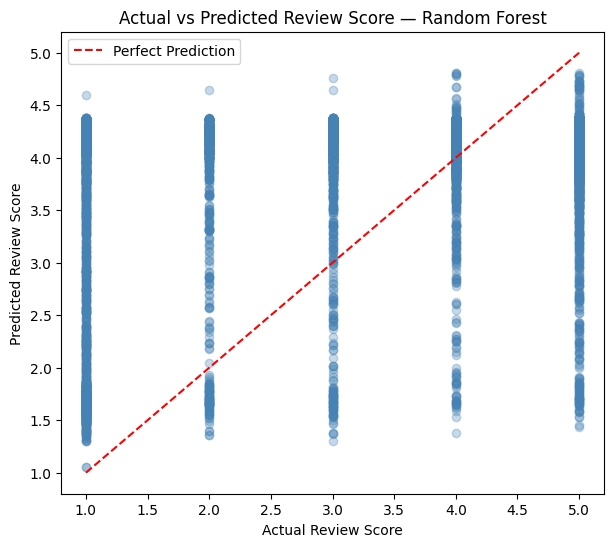

In [10]:
#10 actual vs predicted scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.3, color='steelblue')
plt.plot([1, 5], [1, 5], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Review Score')
plt.ylabel('Predicted Review Score')
plt.title('Actual vs Predicted Review Score — Random Forest')
plt.legend()
plt.show()

C:\Users\yradh\AppData\Local\Temp\ipykernel_11024\938831751.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_feat_imp, x="importance", y="feature", palette="rocket")


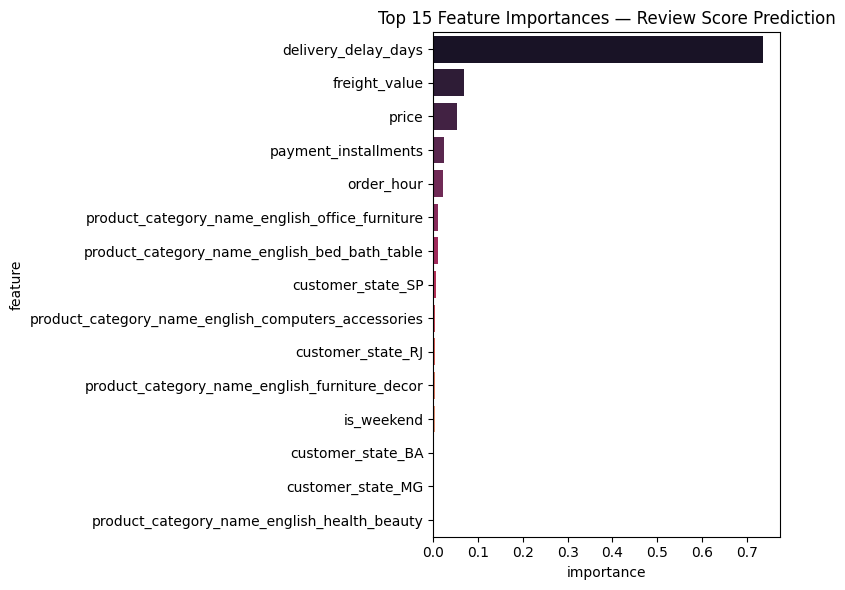

In [11]:
#11 feature importance plot
reg_ohe_cols = rf_reg_pipeline.named_steps["preprocessor"]\
    .named_transformers_["cat"].named_steps["encoder"]\
    .get_feature_names_out(reg_categorical)

reg_all_features = reg_numeric + list(reg_ohe_cols)
reg_importances = rf_reg_pipeline.named_steps["regressor"].feature_importances_

reg_feat_imp = pd.DataFrame({
    "feature": reg_all_features,
    "importance": reg_importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=reg_feat_imp, x="importance", y="feature", palette="rocket")
plt.title("Top 15 Feature Importances — Review Score Prediction")
plt.tight_layout()
plt.show()

In [12]:
joblib.dump(rf_reg_pipeline, "review_score_model.pkl")
print("Model saved as review_score_model.pkl ✅")

Model saved as review_score_model.pkl ✅


## Business Interpretation — Review Score Prediction (Regression)

**Model Performance:** Random Forest Regressor (R² = 0.172) significantly 
outperformed Linear Regression (R² = 0.075), explaining ~17% of variance 
in customer review scores.

**Key Finding:** delivery_delay_days is overwhelmingly the strongest 
predictor of review score — far more influential than price, freight, 
or product category. This directly confirms the SQL chi-square test 
finding that delivery delay significantly impacts review scores.

**Business Recommendation:** Since delivery delay is the single biggest 
controllable driver of customer satisfaction, the late delivery 
prediction model (Phase 1) should be treated as a direct lever for 
improving review scores — proactively flagging at-risk orders for 
logistics intervention will likely have the largest measurable impact 
on platform ratings.

**Limitation:** R² of 0.172 indicates review scores are also influenced 
by factors not captured in this dataset — product quality, packaging 
condition, and subjective customer expectations. This is expected; 
review scores are inherently subjective and cannot be fully predicted 
from structured transactional data alone.